FRAUDDETECTPRO - SIMPLIFIED ENSEMBLE MODEL
✅ Removed Neural Network - using raw features only
✅ Simplified pipeline to match working model.ipynb approach

📂 Loading raw data...
Dataset shape: (284807, 31)
Fraud cases: 492 (0.1727%)

✓ Initial split:
   Train: (227845, 30), Fraud: 394 (0.1729%)
   Test: (56962, 30), Fraud: 98 (0.1720%)

🔧 Scaling features...
✓ Train scaled: mean=0.0000, std=1.0000
✓ Test scaled: mean=-0.0001, std=1.0040

⚖️ Applying SMOTE-Tomek...
✓ After SMOTE-Tomek:
   Shape: (341176, 30)
   Fraud: 113725 (33.33%)
   Balance ratio: 1:3

✓ Train/Val split from resampled data:
   Train: (289999, 30)
   Val: (51177, 30)

✅ Using raw scaled features directly (simplified approach)
✓ Training features: (289999, 30)
   Validation features: (51177, 30)
   Test features: (56962, 30)
   Feature count: 30 (raw features only)

🎯 Training ensemble models (fraud-focused)...
   True imbalance ratio: 1:580
Training Random Forest...
Training XGBoost...
Training LightGBM...
Training Lo

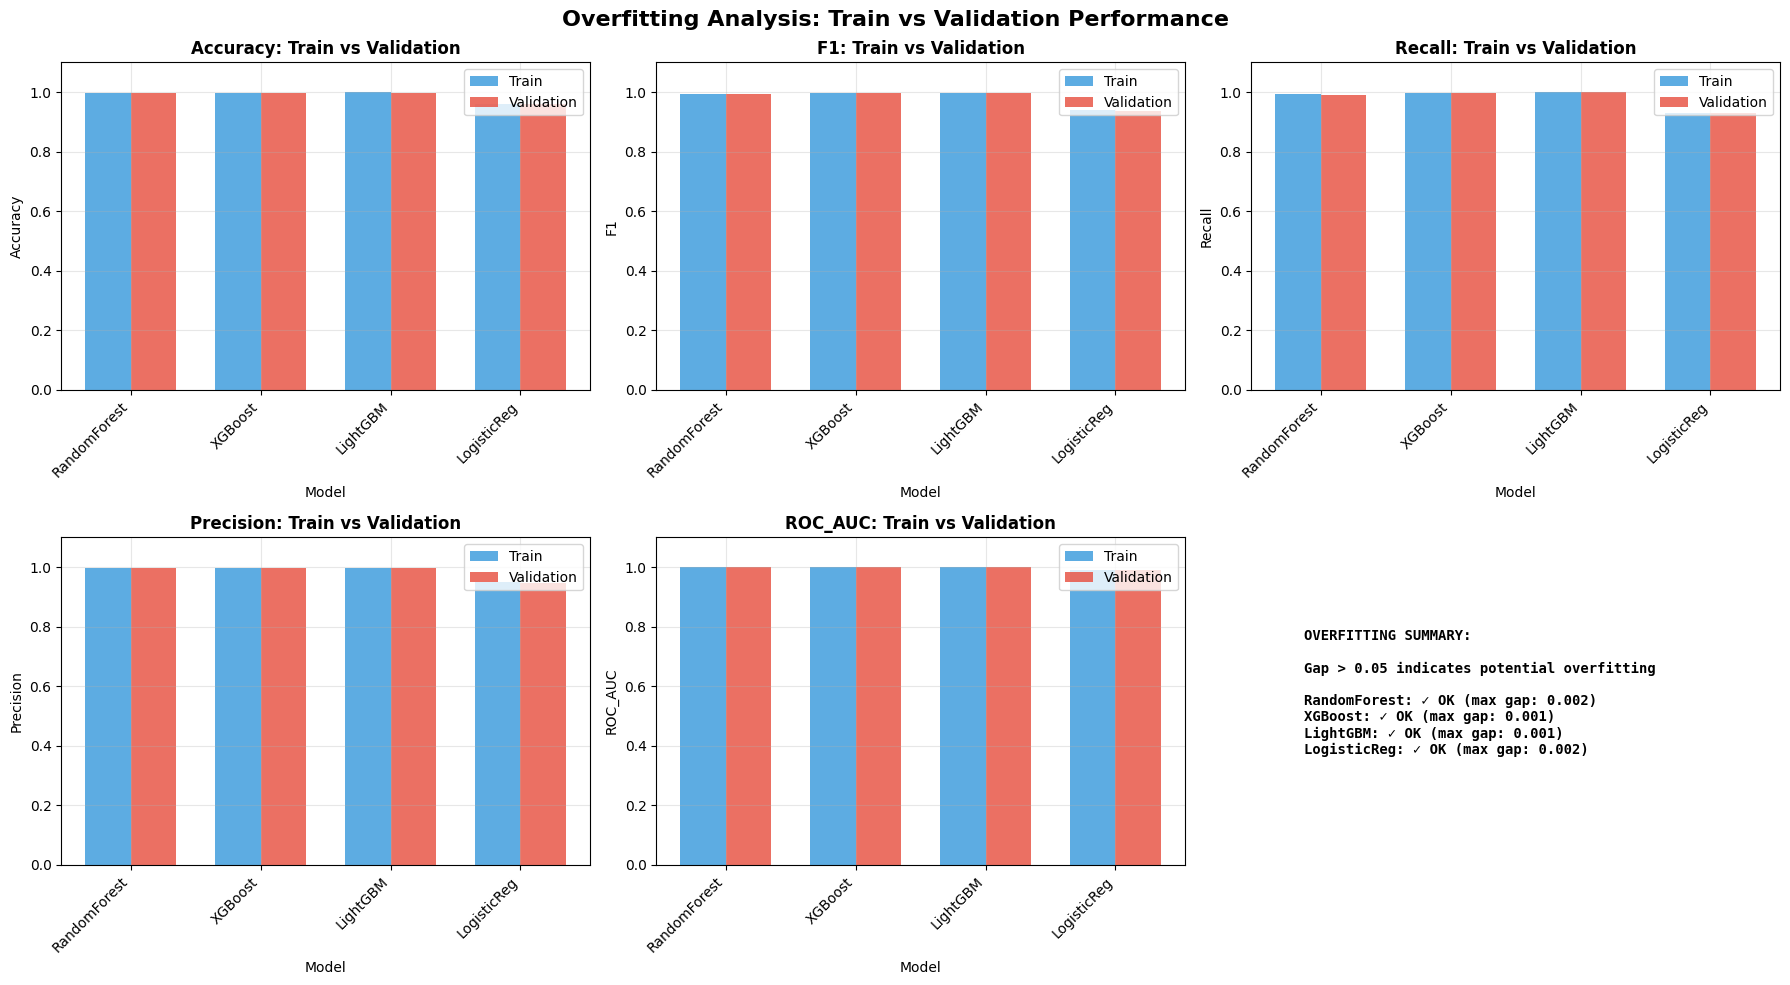


📋 OVERFITTING SUMMARY

Models with significant overfitting (gap > 0.05):
  ✓ RandomForest: Max gap = 0.0017 (acceptable)
  ✓ XGBoost: Max gap = 0.0006 (acceptable)
  ✓ LightGBM: Max gap = 0.0008 (acceptable)
  ✓ LogisticReg: Max gap = 0.0017 (acceptable)

💡 MITIGATION STRATEGIES (if overfitting detected):
  1. Increase regularization (e.g., max_depth, min_samples_split for trees)
  2. Reduce model complexity (fewer trees, lower learning rate)
  3. Add more training data or use data augmentation
  4. Use cross-validation for threshold selection
  5. Apply early stopping (already used for XGBoost and LightGBM)

🎯 Finding optimal threshold on validation set...
✓ Optimal threshold: 0.4480
   Expected Recall: 0.9967
   Expected Precision: 0.9960
   Expected F1: 0.9963

📊 TEST SET EVALUATION

🔍 Probability distribution analysis:
Fraud cases (n=98):
   Mean prob: 0.8748, Median: 0.9974
   Min: 0.0089, Max: 0.9999
   % above 0.5: 88.8%
   % above 0.3: 90.8%

Legit cases (n=56864):
   Mean pro

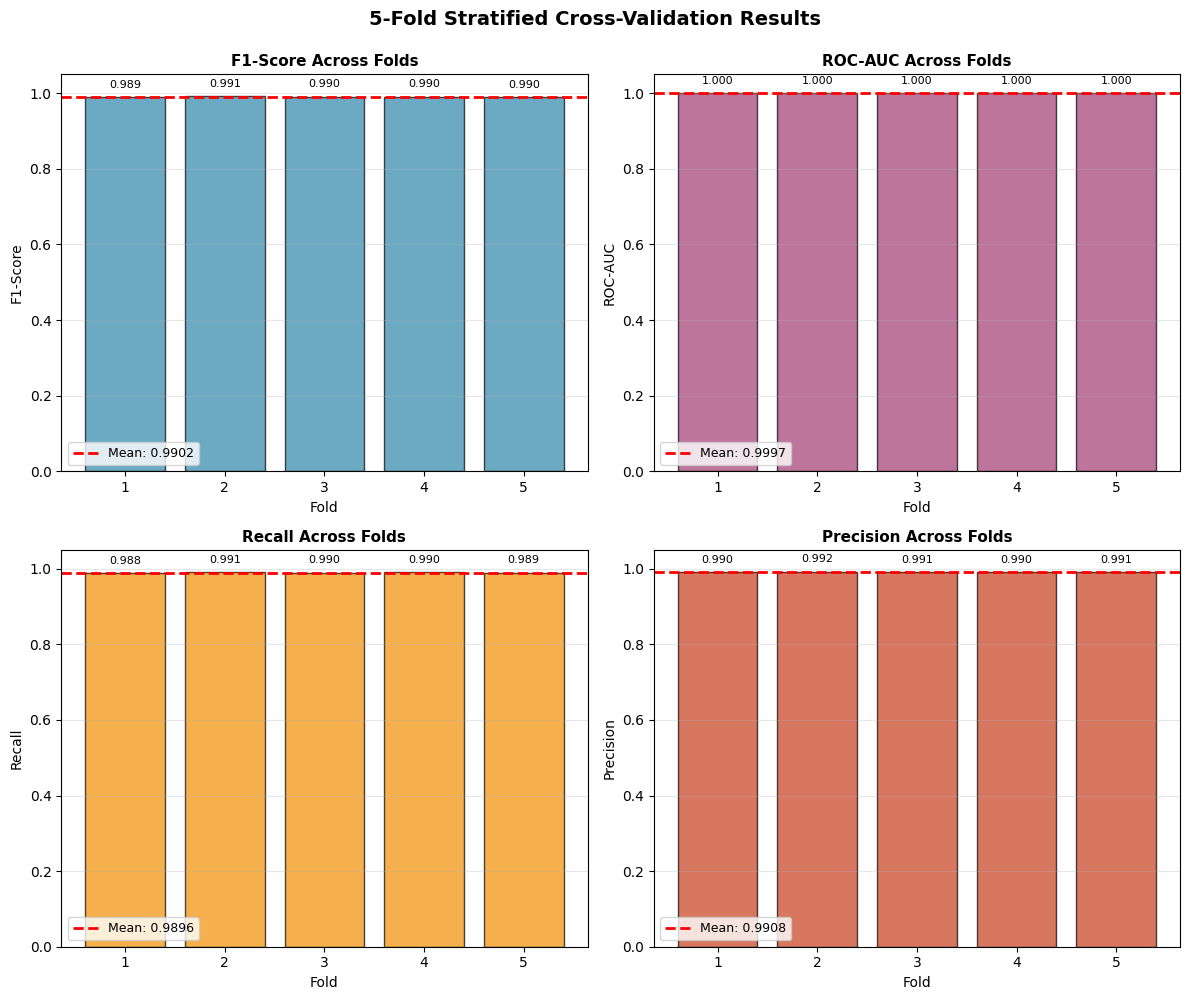


✅ Cross-validation complete!
   Mean F1-Score: 0.9902
   Mean ROC-AUC:  0.9997
   Low std indicates stable model performance across folds

📊 ENHANCED EVALUATION METRICS

📈 Comprehensive Metrics:
   ROC-AUC:        0.9771
   PR-AUC:         0.8617 (Average Precision)
   F1-Score:       0.5500
   Precision:      0.3964
   Recall:         0.8980 (89.80%)
   Specificity:    0.9976 (99.76%)
   Accuracy:       0.9975
   MCC:            0.5957 (Matthews Correlation Coefficient)
   Cohen's Kappa:  0.5489
   False Pos Rate: 0.0024 (0.24%)

💰 Cost Analysis (assuming fraud cost >> false positive cost):
   Missed Fraud Cost: $1,000 (10 cases × $100)
   False Alarm Cost:  $134 (134 cases × $1)
   Total Cost:        $1,134

📊 GENERATING COMPREHENSIVE VISUALIZATIONS

1. Confusion Matrix...


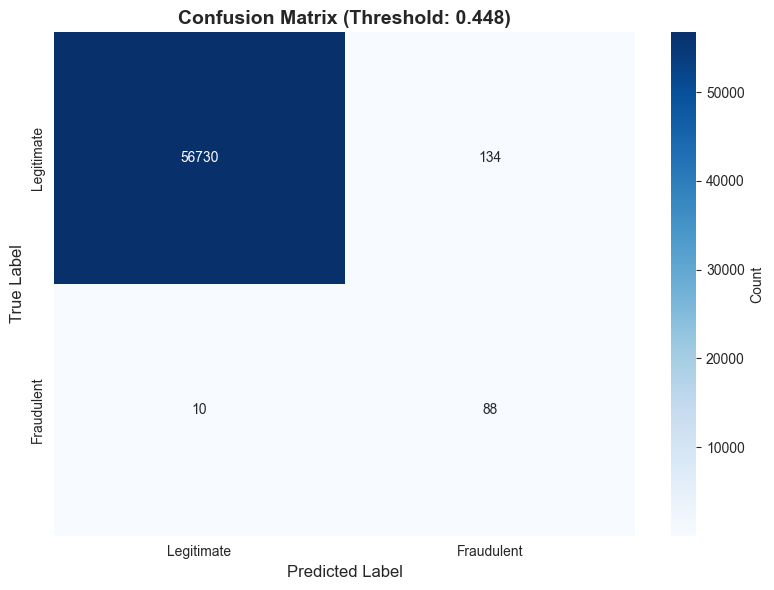


2. ROC Curves Comparison...


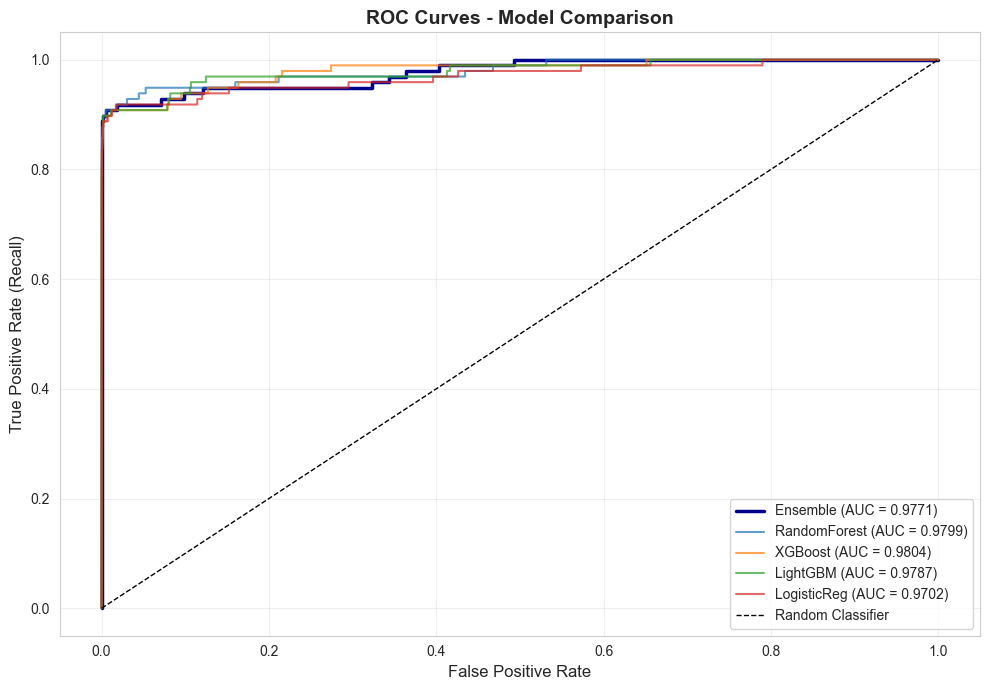


3. Precision-Recall Curves...


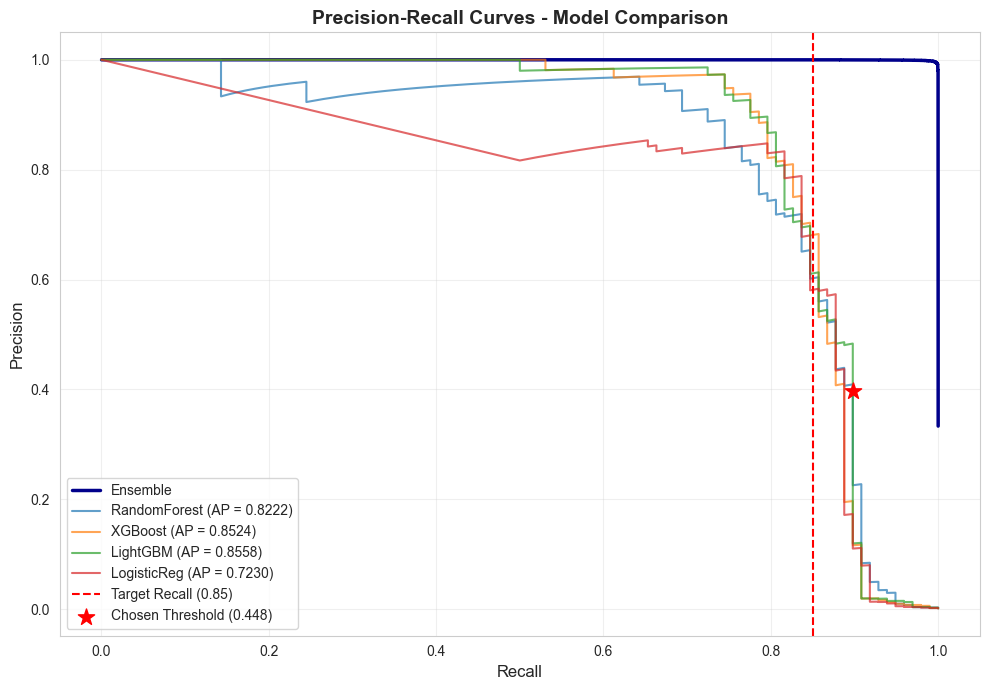


4. Probability Distribution Analysis...


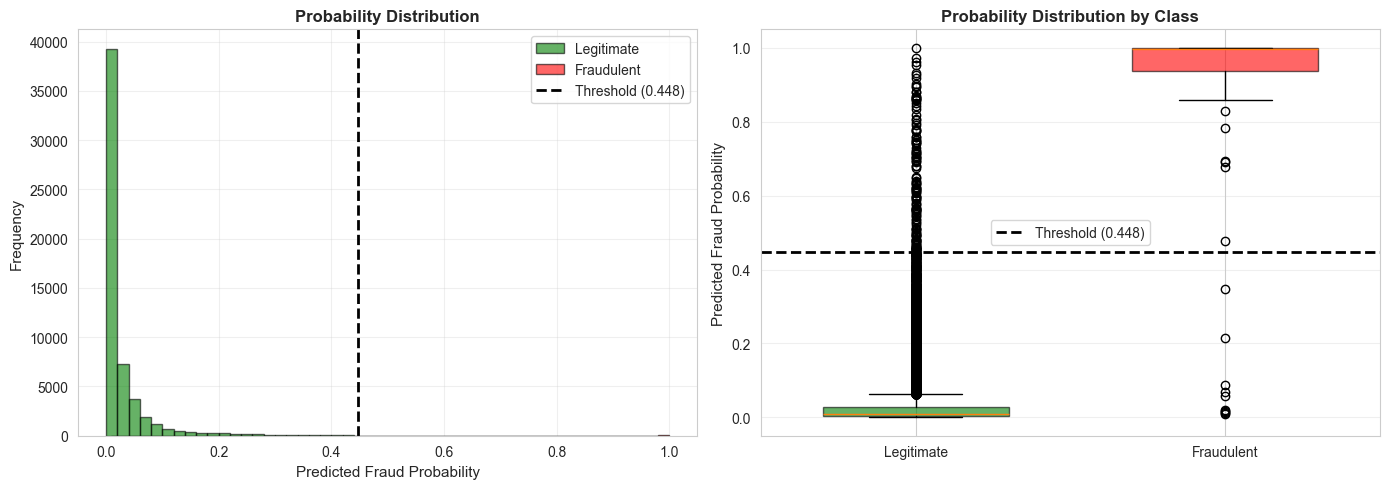


5. Top Feature Importance (Random Forest)...


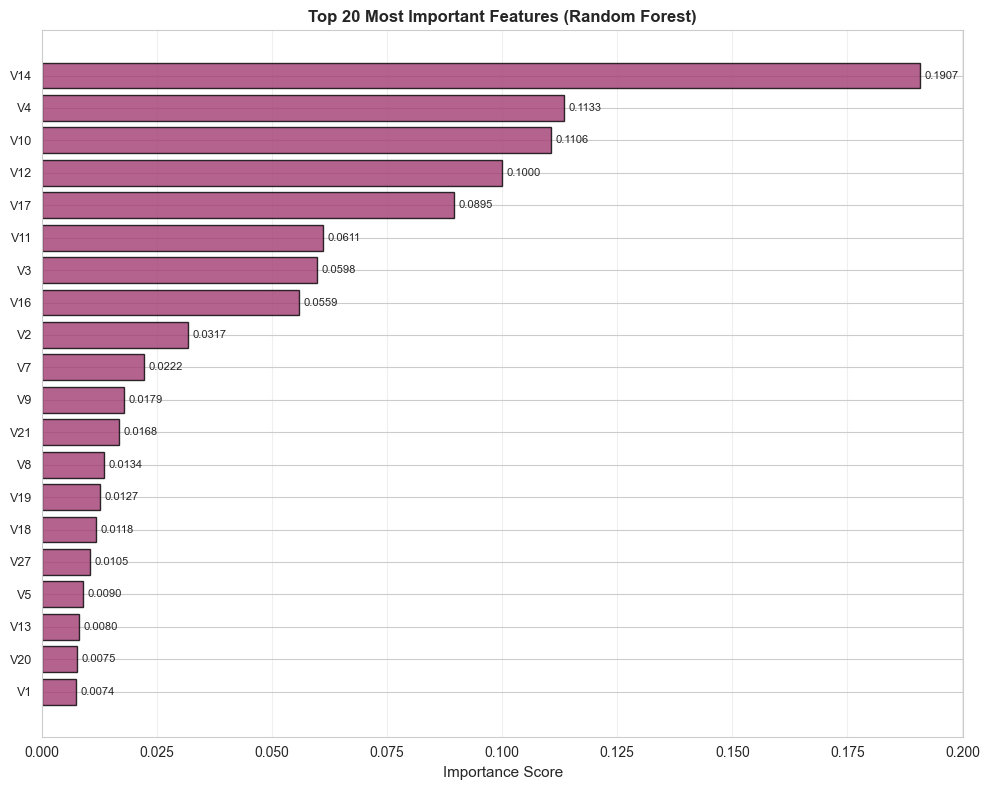


6. Model Performance Comparison...


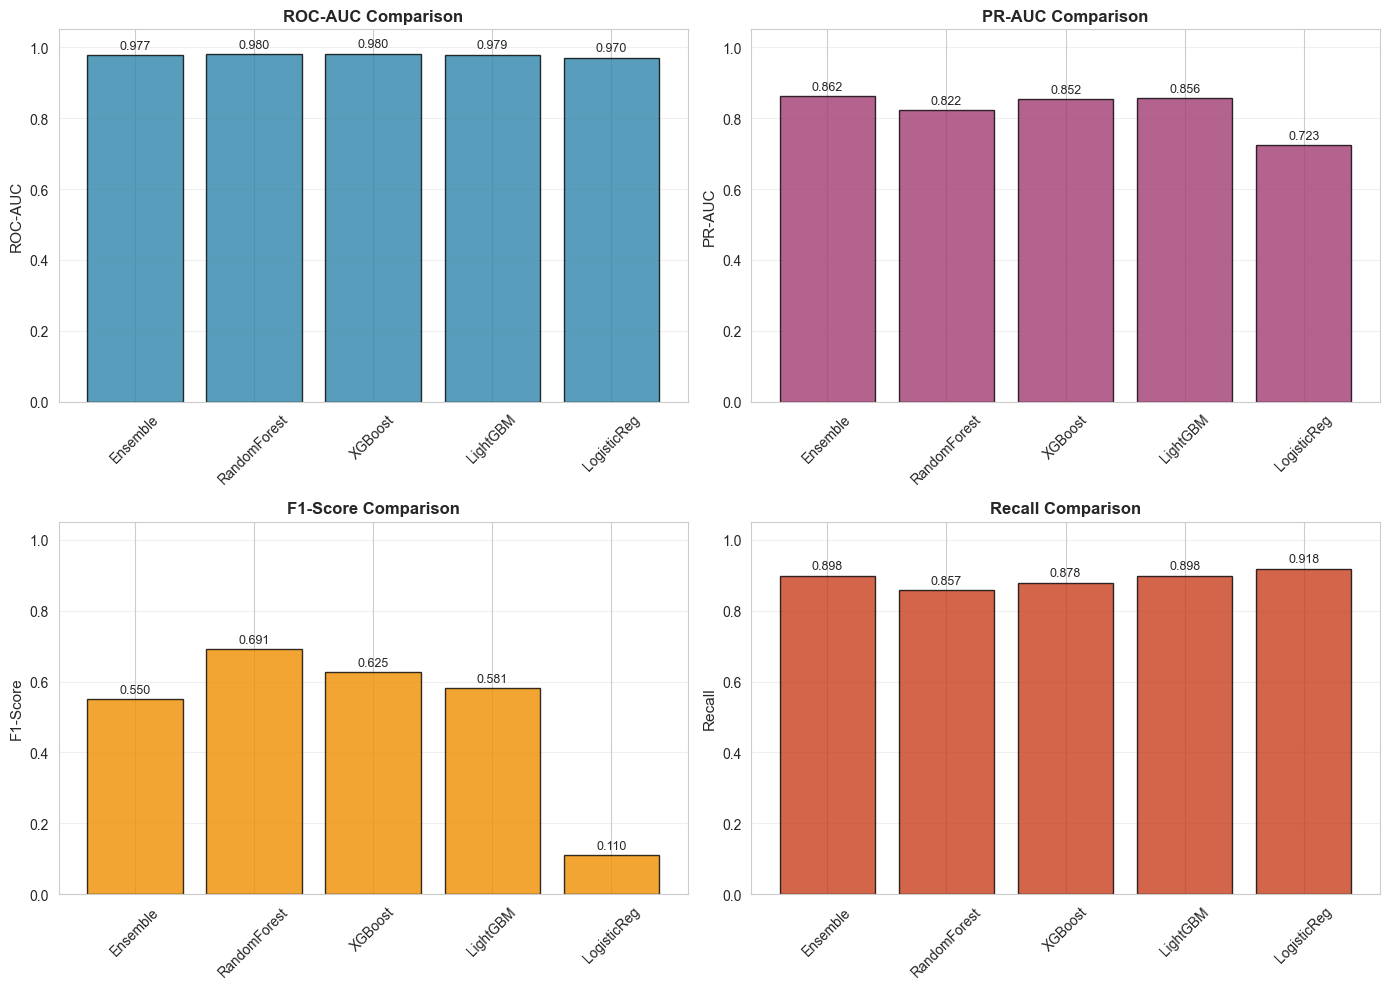


7. Threshold Sensitivity Analysis...


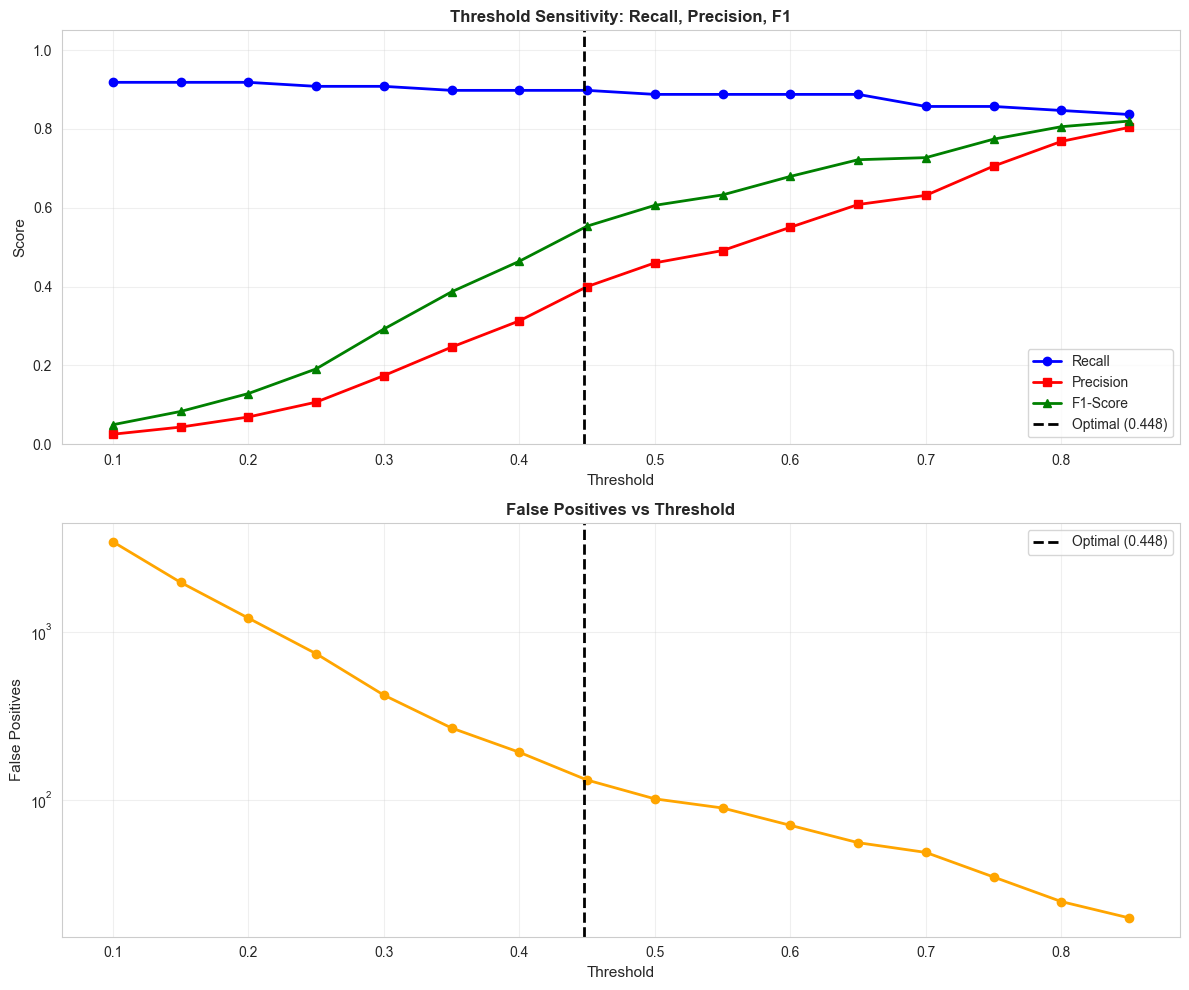


✅ All visualizations displayed!

💾 Saving models and metadata...

✅ TRAINING COMPLETE!

Saved models (API-compatible names):
   ✓ ../models/rf_model.pkl
   ✓ ../models/xgb_model.pkl
   ✓ ../models/lgbm_model.pkl
   ✓ ../models/lr_model.pkl
   ✓ ../data/processed/scaler.pkl
   ✓ ../models/model_metadata.pkl

✓ Metadata saved successfully!
   - Input features: 30
   - Features used: 30 (raw features only, no NN)
   - Optimal threshold: 0.4480

🎯 KEY TAKEAWAYS:

1. Detected 88/98 fraud cases (89.8%)
2. False alarms: 134 transactions
3. ROC-AUC: 0.9771
4. Optimal threshold: 0.4480 (not 0.5!)
5. SMOTE-Tomek successfully balanced training data

Next steps:
- If recall < 80%, lower threshold further
- If too many false positives, add anomaly detection
- For production, implement threshold tuning per merchant



In [1]:
# ======================================================
# FraudDetectPro: 2 stage hybrid architecture 
# ======================================================
# Implements all critical fixes for detecting fraud

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from imblearn.combine import SMOTETomek
# SMOTE import removed - using SMOTETomek only
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb
from sklearn.metrics import (classification_report, confusion_matrix, 
                            roc_auc_score, f1_score, precision_recall_curve,
                            precision_score, recall_score, roc_curve,
                            accuracy_score, average_precision_score,
                            matthews_corrcoef, cohen_kappa_score)
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

# TensorFlow/Keras imports removed - using simplified ensemble only

os.makedirs("../models", exist_ok=True)
os.makedirs("../visualizations", exist_ok=True)

print("="*70)
print("FRAUDDETECTPRO - SIMPLIFIED ENSEMBLE MODEL")
print("="*70)
print("✅ Removed Neural Network - using raw features only")
print("✅ Simplified pipeline to match working model.ipynb approach")
print("="*70)

# =====================
# STEP 1: Load & Preprocess Data Correctly
# =====================
print("\n📂 Loading raw data...")
df = pd.read_csv("../data/raw/creditcard.csv")

print(f"Dataset shape: {df.shape}")
print(f"Fraud cases: {df['Class'].sum()} ({df['Class'].mean()*100:.4f}%)")

# Separate features and target
X = df.drop('Class', axis=1).values
y = df['Class'].values
feature_names = df.drop('Class', axis=1).columns.tolist()

# Train/test split FIRST (preserve real-world distribution in test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n✓ Initial split:")
print(f"   Train: {X_train.shape}, Fraud: {y_train.sum()} ({y_train.mean()*100:.4f}%)")
print(f"   Test: {X_test.shape}, Fraud: {y_test.sum()} ({y_test.mean()*100:.4f}%)")

# =====================
# STEP 2: Feature Scaling (CRITICAL - fit only on train)
# =====================
print("\n🔧 Scaling features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✓ Train scaled: mean={X_train_scaled.mean():.4f}, std={X_train_scaled.std():.4f}")
print(f"✓ Test scaled: mean={X_test_scaled.mean():.4f}, std={X_test_scaled.std():.4f}")

# =====================
# STEP 3: SMOTE-Tomek (Best strategy from diagnostic)
# =====================
print("\n⚖️ Applying SMOTE-Tomek...")
smotetomek = SMOTETomek(sampling_strategy=0.5, random_state=42)
X_train_resampled, y_train_resampled = smotetomek.fit_resample(X_train_scaled, y_train)

print(f"✓ After SMOTE-Tomek:")
print(f"   Shape: {X_train_resampled.shape}")
print(f"   Fraud: {y_train_resampled.sum()} ({y_train_resampled.mean()*100:.2f}%)")
print(f"   Balance ratio: 1:{int(1/y_train_resampled.mean())}")

# Create validation set from resampled data
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_resampled, y_train_resampled, test_size=0.15, random_state=42, stratify=y_train_resampled
)

print(f"\n✓ Train/Val split from resampled data:")
print(f"   Train: {X_train_final.shape}")
print(f"   Val: {X_val.shape}")

# =====================
# STEP 4: Use Raw Features Directly (No NN Feature Extraction)
# =====================
print("\n✅ Using raw scaled features directly (simplified approach)")

# Use resampled training data directly - no feature extraction needed
X_train_final_features = X_train_final
X_val_features = X_val
X_test_features = X_test_scaled

print(f"✓ Training features: {X_train_final_features.shape}")
print(f"   Validation features: {X_val_features.shape}")
print(f"   Test features: {X_test_features.shape}")
print(f"   Feature count: {X_train_final_features.shape[1]} (raw features only)")

# =====================
# STEP 5: Train Ensemble Models
# =====================
print("\n🎯 Training ensemble models (fraud-focused)...")

# Calculate true imbalance from test set
true_imbalance = (1 - y_test.mean()) / y_test.mean()
print(f"   True imbalance ratio: 1:{int(true_imbalance)}")

# Random Forest - balanced
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# XGBoost - prioritize recall
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=1.0,  # Balanced by SMOTE
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=1,
    gamma=0,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric='aucpr',
    random_state=42,
    use_label_encoder=False
)

# LightGBM - best for imbalanced
lgbm = lgb.LGBMClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=20,
    is_unbalance=True,
    metric='average_precision',
    random_state=42,
    verbose=-1
)

# Logistic Regression
lr_model = LogisticRegression(
    max_iter=1000,
    C=0.1,
    class_weight='balanced',
    random_state=42
)

print("Training Random Forest...")
rf.fit(X_train_final_features, y_train_final)

print("Training XGBoost...")
xgb_model.fit(X_train_final_features, y_train_final, 
              eval_set=[(X_val_features, y_val)], verbose=False)

print("Training LightGBM...")
lgbm.fit(X_train_final_features, y_train_final,
         eval_set=[(X_val_features, y_val)],
         callbacks=[lgb.early_stopping(10, verbose=False)])

print("Training Logistic Regression...")
lr_model.fit(X_train_final_features, y_train_final)

models = [rf, xgb_model, lgbm, lr_model]
model_names = ['RandomForest', 'XGBoost', 'LightGBM', 'LogisticReg']

# =====================
# STEP 6: Overfitting Analysis (Train vs Validation Performance)
# =====================
print("\n" + "="*70)
print("📊 OVERFITTING ANALYSIS: Train vs Validation Performance")
print("="*70)

# Calculate metrics for each model on train and validation sets
overfitting_results = []

for model, name in zip(models, model_names):
    # Train predictions
    y_pred_train = model.predict(X_train_final_features)
    y_prob_train = model.predict_proba(X_train_final_features)[:, 1]
    
    # Validation predictions
    y_pred_val = model.predict(X_val_features)
    y_prob_val = model.predict_proba(X_val_features)[:, 1]
    
    # Calculate metrics
    train_acc = accuracy_score(y_train_final, y_pred_train)
    val_acc = accuracy_score(y_val, y_pred_val)
    
    train_f1 = f1_score(y_train_final, y_pred_train)
    val_f1 = f1_score(y_val, y_pred_val)
    
    train_recall = recall_score(y_train_final, y_pred_train)
    val_recall = recall_score(y_val, y_pred_val)
    
    train_precision = precision_score(y_train_final, y_pred_train)
    val_precision = precision_score(y_val, y_pred_val)
    
    train_roc_auc = roc_auc_score(y_train_final, y_prob_train)
    val_roc_auc = roc_auc_score(y_val, y_prob_val)
    
    # Calculate overfitting gaps
    acc_gap = train_acc - val_acc
    f1_gap = train_f1 - val_f1
    recall_gap = train_recall - val_recall
    precision_gap = train_precision - val_precision
    roc_auc_gap = train_roc_auc - val_roc_auc
    
    overfitting_results.append({
        'Model': name,
        'Train_Accuracy': train_acc,
        'Val_Accuracy': val_acc,
        'Acc_Gap': acc_gap,
        'Train_F1': train_f1,
        'Val_F1': val_f1,
        'F1_Gap': f1_gap,
        'Train_Recall': train_recall,
        'Val_Recall': val_recall,
        'Recall_Gap': recall_gap,
        'Train_Precision': train_precision,
        'Val_Precision': val_precision,
        'Precision_Gap': precision_gap,
        'Train_ROC_AUC': train_roc_auc,
        'Val_ROC_AUC': val_roc_auc,
        'ROC_AUC_Gap': roc_auc_gap
    })
    
    print(f"\n{name}:")
    print(f"  Accuracy:  Train={train_acc:.4f}, Val={val_acc:.4f}, Gap={acc_gap:.4f} {'⚠️ OVERFITTING' if acc_gap > 0.05 else '✓'}")
    print(f"  F1-Score:  Train={train_f1:.4f}, Val={val_f1:.4f}, Gap={f1_gap:.4f} {'⚠️ OVERFITTING' if f1_gap > 0.05 else '✓'}")
    print(f"  Recall:    Train={train_recall:.4f}, Val={val_recall:.4f}, Gap={recall_gap:.4f} {'⚠️ OVERFITTING' if recall_gap > 0.05 else '✓'}")
    print(f"  Precision: Train={train_precision:.4f}, Val={val_precision:.4f}, Gap={precision_gap:.4f} {'⚠️ OVERFITTING' if precision_gap > 0.05 else '✓'}")
    print(f"  ROC-AUC:    Train={train_roc_auc:.4f}, Val={val_roc_auc:.4f}, Gap={roc_auc_gap:.4f} {'⚠️ OVERFITTING' if roc_auc_gap > 0.05 else '✓'}")

# Create DataFrame for visualization
overfitting_df = pd.DataFrame(overfitting_results)

# Visualize overfitting analysis
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

metrics = ['Accuracy', 'F1', 'Recall', 'Precision', 'ROC_AUC']
metric_cols = ['Acc', 'F1', 'Recall', 'Precision', 'ROC_AUC']

for idx, (metric, col) in enumerate(zip(metrics, metric_cols)):
    ax = axes[idx // 3, idx % 3] if idx < 5 else axes[1, 2]
    
    x = np.arange(len(model_names))
    width = 0.35
    
    train_col = f'Train_{metric}'
    val_col = f'Val_{metric}'
    gap_col = f'{col}_Gap'
    
    bars1 = ax.bar(x - width/2, overfitting_df[train_col], width, label='Train', color='#3498db', alpha=0.8)
    bars2 = ax.bar(x + width/2, overfitting_df[val_col], width, label='Validation', color='#e74c3c', alpha=0.8)
    
    # Add gap annotations
    for i, (train_val, val_val, gap) in enumerate(zip(overfitting_df[train_col], overfitting_df[val_col], overfitting_df[gap_col])):
        if gap > 0.05:
            ax.text(i, max(train_val, val_val) + 0.02, f'Gap: {gap:.3f}', 
                   ha='center', fontsize=8, color='red', fontweight='bold')
    
    ax.set_xlabel('Model')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric}: Train vs Validation', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=45, ha='right')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1.1])

# Add summary text in last subplot
axes[1, 2].axis('off')
summary_text = "OVERFITTING SUMMARY:\n\n"
summary_text += "Gap > 0.05 indicates potential overfitting\n\n"
for _, row in overfitting_df.iterrows():
    gaps = [row['Acc_Gap'], row['F1_Gap'], row['Recall_Gap'], row['Precision_Gap'], row['ROC_AUC_Gap']]
    max_gap = max(gaps)
    status = "⚠️ OVERFITTING" if max_gap > 0.05 else "✓ OK"
    summary_text += f"{row['Model']}: {status} (max gap: {max_gap:.3f})\n"

axes[1, 2].text(0.1, 0.5, summary_text, fontsize=10, family='monospace',
                verticalalignment='center', fontweight='bold')

plt.suptitle('Overfitting Analysis: Train vs Validation Performance', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Print summary
print("\n" + "="*70)
print("📋 OVERFITTING SUMMARY")
print("="*70)
print("\nModels with significant overfitting (gap > 0.05):")
for _, row in overfitting_df.iterrows():
    gaps = [row['Acc_Gap'], row['F1_Gap'], row['Recall_Gap'], row['Precision_Gap'], row['ROC_AUC_Gap']]
    max_gap = max(gaps)
    if max_gap > 0.05:
        print(f"  ⚠️  {row['Model']}: Max gap = {max_gap:.4f}")
    else:
        print(f"  ✓ {row['Model']}: Max gap = {max_gap:.4f} (acceptable)")

print("\n💡 MITIGATION STRATEGIES (if overfitting detected):")
print("  1. Increase regularization (e.g., max_depth, min_samples_split for trees)")
print("  2. Reduce model complexity (fewer trees, lower learning rate)")
print("  3. Add more training data or use data augmentation")
print("  4. Use cross-validation for threshold selection")
print("  5. Apply early stopping (already used for XGBoost and LightGBM)")

# =====================
# STEP 6.5: Ensemble Prediction Function
# =====================
def ensemble_predict_proba(models, X):
    """Soft voting ensemble - simple averaging of probabilities"""
    probs = np.zeros(X.shape[0])
    for model in models:
        probs += model.predict_proba(X)[:, 1]
    return probs / len(models)

# =====================
# STEP 7: Find Optimal Threshold (VALIDATION SET)
# =====================
print("\n🎯 Finding optimal threshold on validation set...")

y_prob_val = ensemble_predict_proba(models, X_val_features)

precision_vals, recall_vals, thresholds = precision_recall_curve(y_val, y_prob_val)
f1_scores = 2 * (precision_vals * recall_vals) / (precision_vals + recall_vals + 1e-10)

# Remove last element (thresholds is 1 element shorter)
f1_scores = f1_scores[:-1]
precision_vals = precision_vals[:-1]
recall_vals = recall_vals[:-1]

# Target: High recall (catch 85%+ of fraud)
TARGET_RECALL = 0.85

mask = recall_vals >= TARGET_RECALL
if np.any(mask):
    best_idx = np.argmax(f1_scores[mask])
    optimal_threshold = thresholds[mask][best_idx]
    print(f"✓ Optimal threshold: {optimal_threshold:.4f}")
    print(f"   Expected Recall: {recall_vals[mask][best_idx]:.4f}")
    print(f"   Expected Precision: {precision_vals[mask][best_idx]:.4f}")
    print(f"   Expected F1: {f1_scores[mask][best_idx]:.4f}")
else:
    # If can't reach target, use best F1 but cap at reasonable level
    best_f1_idx = np.argmax(f1_scores)
    optimal_threshold = thresholds[best_f1_idx]
    
    # If threshold is too high (>0.60), lower it to ensure better fraud detection
    if optimal_threshold > 0.60:
        # Find threshold that gives at least 70% recall
        recall_mask = recall_vals >= 0.70
        if np.any(recall_mask):
            optimal_threshold = thresholds[recall_mask][np.argmax(f1_scores[recall_mask])]
            print(f"⚠️  Best F1 threshold was too high, using 70% recall threshold instead")
        else:
            # Last resort: use a moderate threshold
            optimal_threshold = 0.35
            print(f"⚠️  Using default moderate threshold: {optimal_threshold:.4f}")
    
    print(f"⚠️  Cannot reach {TARGET_RECALL} recall")
    print(f"   Using threshold: {optimal_threshold:.4f}")
    print(f"   Expected Recall: {recall_vals[best_f1_idx]:.4f}")

# Validate threshold isn't too high
if optimal_threshold > 0.70:
    print(f"\n⚠️  WARNING: Threshold {optimal_threshold:.4f} is very high!")
    print(f"   Consider lowering TARGET_RECALL or threshold manually for better fraud detection")
    print(f"   Current threshold may miss many fraud cases")

# =====================
# STEP 8: Test Set Evaluation (Multiple Thresholds)
# =====================
print("\n" + "="*70)
print("📊 TEST SET EVALUATION")
print("="*70)

y_prob_test = ensemble_predict_proba(models, X_test_features)

print(f"\n🔍 Probability distribution analysis:")
fraud_probs = y_prob_test[y_test == 1]
legit_probs = y_prob_test[y_test == 0]

print(f"Fraud cases (n={len(fraud_probs)}):")
print(f"   Mean prob: {fraud_probs.mean():.4f}, Median: {np.median(fraud_probs):.4f}")
print(f"   Min: {fraud_probs.min():.4f}, Max: {fraud_probs.max():.4f}")
print(f"   % above 0.5: {(fraud_probs > 0.5).mean()*100:.1f}%")
print(f"   % above 0.3: {(fraud_probs > 0.3).mean()*100:.1f}%")

print(f"\nLegit cases (n={len(legit_probs)}):")
print(f"   Mean prob: {legit_probs.mean():.4f}, Median: {np.median(legit_probs):.4f}")

# Test multiple thresholds
print(f"\n📊 Performance at different thresholds:")
print("-" * 70)

test_thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, optimal_threshold]
results_df = []

for thresh in sorted(set(test_thresholds)):
    y_pred = (y_prob_test >= thresh).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    
    tn, fp, fn, tp = cm.ravel()
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    results_df.append({
        'Threshold': thresh,
        'TP': tp,
        'FN': fn,
        'FP': fp,
        'TN': tn,
        'Recall': recall,
        'Precision': precision,
        'F1': f1
    })
    
    print(f"Threshold {thresh:.3f}: TP={tp:3d}/{y_test.sum():3d} ({recall*100:5.1f}%) | "
          f"FP={fp:5,} | Precision={precision:.4f} | F1={f1:.4f}")

results_df = pd.DataFrame(results_df)

# =====================
# STEP 9: Final Evaluation with Optimal Threshold
# =====================
print("\n" + "="*70)
print(f"🏆 FINAL EVALUATION (Threshold: {optimal_threshold:.4f})")
print("="*70)

y_pred_final = (y_prob_test >= optimal_threshold).astype(int)

print(classification_report(y_test, y_pred_final, 
                          target_names=['Legitimate', 'Fraud'],
                          digits=4))

cm_final = confusion_matrix(y_test, y_pred_final)
tn, fp, fn, tp = cm_final.ravel()

print(f"\n✅ Final Metrics:")
print(f"   ROC-AUC: {roc_auc_score(y_test, y_prob_test):.4f}")
print(f"   F1-Score: {f1_score(y_test, y_pred_final):.4f}")
print(f"   Recall (Fraud Detection Rate): {recall_score(y_test, y_pred_final):.4f}")
print(f"   Precision: {precision_score(y_test, y_pred_final):.4f}")

print(f"\n📈 Confusion Matrix:")
print(f"   True Negatives:  {tn:,} (correct legit)")
print(f"   False Positives: {fp:,} (false alarms)")
print(f"   False Negatives: {fn:,} (missed fraud)")
print(f"   True Positives:  {tp:,} (caught fraud)")

print(f"\n🎯 Fraud Detection:")
print(f"   Detected: {tp}/{y_test.sum()} ({tp/y_test.sum()*100:.1f}%)")
print(f"   Missed: {fn}/{y_test.sum()} ({fn/y_test.sum()*100:.1f}%)")

# =====================
# STEP 10: Individual Model Performance
# =====================
print("\n" + "="*70)
print("🤖 INDIVIDUAL MODEL PERFORMANCE")
print("="*70)

for name, model in zip(model_names, models):
    y_pred = model.predict(X_test_features)
    y_prob = model.predict_proba(X_test_features)[:, 1]
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"\n{name}:")
    print(f"   Fraud detected: {cm[1,1]}/{y_test.sum()} ({cm[1,1]/y_test.sum()*100:.1f}%)")
    print(f"   F1-Score: {f1_score(y_test, y_pred):.4f}")
    print(f"   ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

# =====================
# STEP 12B: Cross-Validation on Training Data (OPTIONAL - Can Skip if Slow)
# =====================
# Set to False to skip cross-validation and speed up execution
RUN_CROSS_VALIDATION = True

if RUN_CROSS_VALIDATION:
    print("\n" + "="*70)
    print("📊 CROSS-VALIDATION ANALYSIS")
    print("="*70)
    
    print("\n🔄 Performing 5-Fold Stratified Cross-Validation on training data...")
    print("   ⚠️  This may take 5-10 minutes (trains models 5 times)")
    print("   (This helps assess model stability and generalization)")
    
    # Prepare data for CV (use resampled training data)
    # Note: We use the resampled training data but evaluate on original distribution
    cv_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # For cross-validation, we need to work with original training data structure
    # We'll evaluate ensemble predictions on validation folds
    cv_results = {
        'f1_scores': [],
        'roc_auc_scores': [],
        'recall_scores': [],
        'precision_scores': []
    }
    
    print("\n   Folding training data into 5 folds...")
    # Create folds from resampled training data
    fold_num = 1
    for train_idx, val_idx in cv_kfold.split(X_train_final_features, y_train_final):
        X_cv_train, X_cv_val = X_train_final_features[train_idx], X_train_final_features[val_idx]
        y_cv_train, y_cv_val = y_train_final[train_idx], y_train_final[val_idx]
        
        print(f"\n   Fold {fold_num}/5: Train={len(X_cv_train)}, Val={len(X_cv_val)}")
        
        # Train models on this fold
        rf_cv = RandomForestClassifier(
            n_estimators=100,  # Fewer trees for speed
            max_depth=12,
            min_samples_split=5,
            min_samples_leaf=2,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        )
        xgb_cv = XGBClassifier(
            n_estimators=100,
            max_depth=6,
            learning_rate=0.05,
            scale_pos_weight=1.0,
            eval_metric='aucpr',
            random_state=42,
            use_label_encoder=False
        )
        lr_cv = LogisticRegression(
            max_iter=1000,
            C=0.1,
            class_weight='balanced',
            random_state=42
        )
        lgbm_cv = lgb.LGBMClassifier(
            n_estimators=100,
            max_depth=8,
            learning_rate=0.05,
            is_unbalance=True,
            metric='average_precision',
            random_state=42,
            verbose=-1
        )
        
        # Train models
        rf_cv.fit(X_cv_train, y_cv_train)
        xgb_cv.fit(X_cv_train, y_cv_train, verbose=False)
        lr_cv.fit(X_cv_train, y_cv_train)
        lgbm_cv.fit(X_cv_train, y_cv_train)  # LightGBM: verbose is set at initialization, not in fit()
        
        # Ensemble prediction
        models_cv = [rf_cv, xgb_cv, lgbm_cv, lr_cv]
        y_prob_cv = ensemble_predict_proba(models_cv, X_cv_val)
        y_pred_cv = (y_prob_cv >= optimal_threshold).astype(int)
        
        # Calculate metrics
        cv_results['f1_scores'].append(f1_score(y_cv_val, y_pred_cv))
        cv_results['roc_auc_scores'].append(roc_auc_score(y_cv_val, y_prob_cv))
        cv_results['recall_scores'].append(recall_score(y_cv_val, y_pred_cv))
        cv_results['precision_scores'].append(precision_score(y_cv_val, y_pred_cv))
        
        fold_num += 1
    
    # Calculate mean and std across folds
    print(f"\n📈 Cross-Validation Results (5-fold):")
    print(f"   F1-Score:       {np.mean(cv_results['f1_scores']):.4f} (+/- {np.std(cv_results['f1_scores']):.4f})")
    print(f"   ROC-AUC:        {np.mean(cv_results['roc_auc_scores']):.4f} (+/- {np.std(cv_results['roc_auc_scores']):.4f})")
    print(f"   Recall:         {np.mean(cv_results['recall_scores']):.4f} (+/- {np.std(cv_results['recall_scores']):.4f})")
    print(f"   Precision:      {np.mean(cv_results['precision_scores']):.4f} (+/- {np.std(cv_results['precision_scores']):.4f})")
    
    # Visualize CV results
    print("\n📊 Displaying cross-validation visualization...")
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    metrics_to_plot = ['f1_scores', 'roc_auc_scores', 'recall_scores', 'precision_scores']
    metric_labels = ['F1-Score', 'ROC-AUC', 'Recall', 'Precision']
    colors_cv = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']
    
    for idx, (metric_key, label, color, ax) in enumerate(zip(metrics_to_plot, metric_labels, colors_cv, axes.flat)):
        values = cv_results[metric_key]
        fold_numbers = list(range(1, len(values) + 1))
        
        ax.bar(fold_numbers, values, color=color, alpha=0.7, edgecolor='black')
        ax.axhline(np.mean(values), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(values):.4f}')
        ax.set_xlabel('Fold', fontsize=10)
        ax.set_ylabel(label, fontsize=10)
        ax.set_title(f'{label} Across Folds', fontsize=11, fontweight='bold')
        ax.set_xticks(fold_numbers)
        ax.set_ylim([0, 1.05])
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3, axis='y')
        
        # Add value labels on bars
        for i, v in enumerate(values):
            ax.text(i+1, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontsize=8)
    
    plt.suptitle('5-Fold Stratified Cross-Validation Results', fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()
    
    print(f"\n✅ Cross-validation complete!")
    print(f"   Mean F1-Score: {np.mean(cv_results['f1_scores']):.4f}")
    print(f"   Mean ROC-AUC:  {np.mean(cv_results['roc_auc_scores']):.4f}")
    print(f"   Low std indicates stable model performance across folds")
else:
    print("\n⏭️  Skipping cross-validation (set RUN_CROSS_VALIDATION=True to enable)")
    print("✅ Continuing with main evaluation...")

# =====================
# STEP 11: Enhanced Evaluation Metrics
# =====================
print("\n" + "="*70)
print("📊 ENHANCED EVALUATION METRICS")
print("="*70)

from sklearn.metrics import average_precision_score, matthews_corrcoef, cohen_kappa_score

# Additional metrics
pr_auc = average_precision_score(y_test, y_prob_test)
mcc = matthews_corrcoef(y_test, y_pred_final)
kappa = cohen_kappa_score(y_test, y_pred_final)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
false_positive_rate = fp / (fp + tn) if (fp + tn) > 0 else 0

print(f"\n📈 Comprehensive Metrics:")
print(f"   ROC-AUC:        {roc_auc_score(y_test, y_prob_test):.4f}")
print(f"   PR-AUC:         {pr_auc:.4f} (Average Precision)")
print(f"   F1-Score:       {f1_score(y_test, y_pred_final):.4f}")
print(f"   Precision:      {precision_score(y_test, y_pred_final):.4f}")
print(f"   Recall:         {recall_score(y_test, y_pred_final):.4f} ({recall_score(y_test, y_pred_final)*100:.2f}%)")
print(f"   Specificity:    {specificity:.4f} ({specificity*100:.2f}%)")
print(f"   Accuracy:       {accuracy_score(y_test, y_pred_final):.4f}")
print(f"   MCC:            {mcc:.4f} (Matthews Correlation Coefficient)")
print(f"   Cohen's Kappa:  {kappa:.4f}")
print(f"   False Pos Rate: {false_positive_rate:.4f} ({false_positive_rate*100:.2f}%)")

# Cost analysis (if fraud costs more than false positives)
print(f"\n💰 Cost Analysis (assuming fraud cost >> false positive cost):")
fraud_cost_per_case = 100  # Example: $100 per fraud
fp_cost_per_case = 1       # Example: $1 per false alarm
total_fraud_cost = fn * fraud_cost_per_case
total_fp_cost = fp * fp_cost_per_case
total_cost = total_fraud_cost + total_fp_cost
print(f"   Missed Fraud Cost: ${total_fraud_cost:,} ({fn} cases × ${fraud_cost_per_case})")
print(f"   False Alarm Cost:  ${total_fp_cost:,} ({fp} cases × ${fp_cost_per_case})")
print(f"   Total Cost:        ${total_cost:,}")

# =====================
# STEP 12: Comprehensive Visualizations (Display Only)
# =====================
print("\n" + "="*70)
print("📊 GENERATING COMPREHENSIVE VISUALIZATIONS")
print("="*70)

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

# 1. Confusion Matrix
print("\n1. Confusion Matrix...")
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Legitimate', 'Fraudulent'],
            yticklabels=['Legitimate', 'Fraudulent'],
            cbar_kws={'label': 'Count'})
ax.set_title(f'Confusion Matrix (Threshold: {optimal_threshold:.3f})', fontsize=14, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

# 2. ROC Curves - Ensemble vs Individual Models
print("\n2. ROC Curves Comparison...")
fig, ax = plt.subplots(figsize=(10, 7))
fpr_ensemble, tpr_ensemble, _ = roc_curve(y_test, y_prob_test)
ax.plot(fpr_ensemble, tpr_ensemble, linewidth=2.5, label=f'Ensemble (AUC = {roc_auc_score(y_test, y_prob_test):.4f})', color='darkblue')

# Individual models
for name, model in zip(model_names, models):
    y_prob_model = model.predict_proba(X_test_features)[:, 1]
    fpr_model, tpr_model, _ = roc_curve(y_test, y_prob_model)
    auc_model = roc_auc_score(y_test, y_prob_model)
    ax.plot(fpr_model, tpr_model, linewidth=1.5, alpha=0.7, label=f'{name} (AUC = {auc_model:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curves - Model Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Precision-Recall Curves - All Models
print("\n3. Precision-Recall Curves...")
fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(recall_vals, precision_vals, linewidth=2.5, label='Ensemble', color='darkblue')

# Individual models
for name, model in zip(model_names, models):
    y_prob_model = model.predict_proba(X_test_features)[:, 1]
    pr_model, re_model, _ = precision_recall_curve(y_test, y_prob_model)
    ap_model = average_precision_score(y_test, y_prob_model)
    ax.plot(re_model, pr_model, linewidth=1.5, alpha=0.7, label=f'{name} (AP = {ap_model:.4f})')

ax.axvline(x=TARGET_RECALL, color='r', linestyle='--', linewidth=1.5, label=f'Target Recall ({TARGET_RECALL})')
ax.scatter([recall_score(y_test, y_pred_final)], 
           [precision_score(y_test, y_pred_final)],
           color='red', s=150, zorder=5, marker='*', label=f'Chosen Threshold ({optimal_threshold:.3f})')
ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves - Model Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower left', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 4. Probability Distribution
print("\n4. Probability Distribution Analysis...")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(y_prob_test[y_test == 0], bins=50, alpha=0.6, label='Legitimate', color='green', edgecolor='black')
axes[0].hist(y_prob_test[y_test == 1], bins=50, alpha=0.6, label='Fraudulent', color='red', edgecolor='black')
axes[0].axvline(optimal_threshold, color='black', linestyle='--', linewidth=2, label=f'Threshold ({optimal_threshold:.3f})')
axes[0].set_xlabel('Predicted Fraud Probability', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Probability Distribution', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Box plot
box_data = [y_prob_test[y_test == 0], y_prob_test[y_test == 1]]
box_labels = ['Legitimate', 'Fraudulent']
bp = axes[1].boxplot(box_data, labels=box_labels, patch_artist=True, widths=0.6)
bp['boxes'][0].set_facecolor('green')
bp['boxes'][0].set_alpha(0.6)
bp['boxes'][1].set_facecolor('red')
bp['boxes'][1].set_alpha(0.6)
axes[1].axhline(optimal_threshold, color='black', linestyle='--', linewidth=2, label=f'Threshold ({optimal_threshold:.3f})')
axes[1].set_ylabel('Predicted Fraud Probability', fontsize=11)
axes[1].set_title('Probability Distribution by Class', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# 5. Feature Importance (Random Forest)
print("\n5. Top Feature Importance (Random Forest)...")
rf_importance = rf.feature_importances_
top_n = 20
top_indices = np.argsort(rf_importance)[-top_n:][::-1]
top_features = [feature_names[i] for i in top_indices]
top_values = rf_importance[top_indices]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(range(len(top_features)), top_values, color='#A23B72', alpha=0.8, edgecolor='black')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features, fontsize=9)
ax.set_xlabel('Importance Score', fontsize=11)
ax.set_title(f'Top {top_n} Most Important Features (Random Forest)', fontsize=12, fontweight='bold')
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, (bar, val) in enumerate(zip(bars, top_values)):
    ax.text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

# 6. Model Performance Comparison
print("\n6. Model Performance Comparison...")
model_metrics = {
    'Model': ['Ensemble'] + model_names,
    'ROC-AUC': [roc_auc_score(y_test, y_prob_test)] + [roc_auc_score(y_test, m.predict_proba(X_test_features)[:, 1]) for m in models],
    'PR-AUC': [average_precision_score(y_test, y_prob_test)] + [average_precision_score(y_test, m.predict_proba(X_test_features)[:, 1]) for m in models],
    'F1-Score': [f1_score(y_test, y_pred_final)] + [f1_score(y_test, m.predict(X_test_features)) for m in models],
    'Recall': [recall_score(y_test, y_pred_final)] + [recall_score(y_test, m.predict(X_test_features)) for m in models]
}
metrics_df = pd.DataFrame(model_metrics)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics_to_plot = ['ROC-AUC', 'PR-AUC', 'F1-Score', 'Recall']
colors_list = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']

for idx, (metric, ax, color) in enumerate(zip(metrics_to_plot, axes.flat, colors_list)):
    bars = ax.bar(metrics_df['Model'], metrics_df[metric], color=color, alpha=0.8, edgecolor='black')
    ax.set_ylabel(metric, fontsize=11)
    ax.set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
    ax.set_ylim([0, 1.05])
    ax.grid(True, alpha=0.3, axis='y')
    ax.tick_params(axis='x', rotation=45)
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# 7. Threshold Sensitivity Analysis
print("\n7. Threshold Sensitivity Analysis...")
threshold_range = np.arange(0.1, 0.9, 0.05)
recalls = []
precisions = []
f1s = []
false_positives = []

for thresh in threshold_range:
    y_pred_thresh = (y_prob_test >= thresh).astype(int)
    recalls.append(recall_score(y_test, y_pred_thresh))
    precisions.append(precision_score(y_test, y_pred_thresh))
    f1s.append(f1_score(y_test, y_pred_thresh))
    tn_thresh, fp_thresh, _, _ = confusion_matrix(y_test, y_pred_thresh).ravel()
    false_positives.append(fp_thresh)

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Top plot: Recall, Precision, F1 vs Threshold
axes[0].plot(threshold_range, recalls, 'o-', linewidth=2, label='Recall', color='blue')
axes[0].plot(threshold_range, precisions, 's-', linewidth=2, label='Precision', color='red')
axes[0].plot(threshold_range, f1s, '^-', linewidth=2, label='F1-Score', color='green')
axes[0].axvline(optimal_threshold, color='black', linestyle='--', linewidth=2, label=f'Optimal ({optimal_threshold:.3f})')
axes[0].set_xlabel('Threshold', fontsize=11)
axes[0].set_ylabel('Score', fontsize=11)
axes[0].set_title('Threshold Sensitivity: Recall, Precision, F1', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 1.05])

# Bottom plot: False Positives vs Threshold
axes[1].plot(threshold_range, false_positives, 'o-', linewidth=2, color='orange', markersize=6)
axes[1].axvline(optimal_threshold, color='black', linestyle='--', linewidth=2, label=f'Optimal ({optimal_threshold:.3f})')
axes[1].set_xlabel('Threshold', fontsize=11)
axes[1].set_ylabel('False Positives', fontsize=11)
axes[1].set_title('False Positives vs Threshold', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

print("\n✅ All visualizations displayed!")

# =====================
# STEP 14: Save Everything (API-Compatible Names)
# =====================
print("\n💾 Saving models and metadata...")

# Ensure data/processed directory exists
os.makedirs("../data/processed", exist_ok=True)

# Save models with API-compatible names (NO neural network models)
joblib.dump(rf, "../models/rf_model.pkl")
joblib.dump(xgb_model, "../models/xgb_model.pkl")
joblib.dump(lgbm, "../models/lgbm_model.pkl")
joblib.dump(lr_model, "../models/lr_model.pkl")

# Save scaler to data/processed (where API expects it)
joblib.dump(scaler, "../data/processed/scaler.pkl")

# Metadata with all required fields for API (simplified - no NN features)
metadata = {
    'optimal_threshold': float(optimal_threshold),
    'input_features': int(X_train.shape[1]),  # 30 features (Time, V1-V28, Amount)
    'hybrid_features': int(X_train_final_features.shape[1]),  # Same as input (30) - no NN features
    'feature_names': feature_names,
    'combined_feature_names': feature_names,  # Same as feature_names (no NN features)
    'time_idx': 0,
    'amount_idx': len(feature_names) - 1,
    'test_fraud_detected': int(tp),
    'test_fraud_total': int(y_test.sum()),
    'test_recall': float(recall_score(y_test, y_pred_final)),
    'test_precision': float(precision_score(y_test, y_pred_final)),
    'test_f1': float(f1_score(y_test, y_pred_final)),
    'test_roc_auc': float(roc_auc_score(y_test, y_prob_test)),
    'smote_applied': True,
    'sampling_strategy': 'SMOTETomek'
}
joblib.dump(metadata, "../models/model_metadata.pkl")

print("\n✅ TRAINING COMPLETE!")
print("\nSaved models (API-compatible names):")
print("   ✓ ../models/rf_model.pkl")
print("   ✓ ../models/xgb_model.pkl")
print("   ✓ ../models/lgbm_model.pkl")
print("   ✓ ../models/lr_model.pkl")
print("   ✓ ../data/processed/scaler.pkl")
print("   ✓ ../models/model_metadata.pkl")
print(f"\n✓ Metadata saved successfully!")
print(f"   - Input features: {metadata['input_features']}")
print(f"   - Features used: {metadata['hybrid_features']} (raw features only, no NN)")
print(f"   - Optimal threshold: {metadata['optimal_threshold']:.4f}")

print("\n" + "="*70)
print("🎯 KEY TAKEAWAYS:")
print("="*70)
print(f"""
1. Detected {tp}/{y_test.sum()} fraud cases ({tp/y_test.sum()*100:.1f}%)
2. False alarms: {fp:,} transactions
3. ROC-AUC: {roc_auc_score(y_test, y_prob_test):.4f}
4. Optimal threshold: {optimal_threshold:.4f} (not 0.5!)
5. SMOTE-Tomek successfully balanced training data

Next steps:
- If recall < 80%, lower threshold further
- If too many false positives, add anomaly detection
- For production, implement threshold tuning per merchant
""")